# 하이브리드 고장진단 파이프라인
## Stage 1 : 1D-CNN → Normal vs Fault 판별
## Stage 2 : 2D-CNN (STFT 스펙트로그램) → Type1 / Type2 / Type3 유형 분류

---
**처리 흐름**
1. 데이터 로드 및 전처리 (공통)
2. 1D-CNN 학습 (이진: Normal=0, Fault=1)
3. 1D-CNN 추론 → Fault 판별된 데이터만 저장 (`.npz`)
4. 저장된 Fault 데이터 로드 → STFT 변환
5. 2D-CNN 학습 (Type1=0 / Type2=1 / Type3=2)
6. 최종 평가 및 시각화

In [1]:
!pip install numpy pandas scipy scikit-learn torch matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable


In [2]:
# ──────────────────────────────────────────────────────────────
# 0.  라이브러리
# ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import time, os
from scipy import interpolate
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import TensorDataset, DataLoader

DATA_PATH  = r'C:/Users/SPAC6/Desktop/python data/data/'
SAVE_PATH  = r'C:/Users/SPAC6/Desktop/python data/형민/save/Hybrid/'
os.makedirs(SAVE_PATH, exist_ok=True)
print('경로 설정 완료')
print('DATA_PATH :', DATA_PATH)
print('SAVE_PATH :', SAVE_PATH)

경로 설정 완료
DATA_PATH : C:/Users/SPAC6/Desktop/python data/data/
SAVE_PATH : C:/Users/SPAC6/Desktop/python data/형민/save/Hybrid/


In [3]:
# ──────────────────────────────────────────────────────────────
# 1.  CSV 로드  (names= 이용, header 없음)
# ──────────────────────────────────────────────────────────────
sensor1 = pd.read_csv(DATA_PATH + 'g1_sensor1.csv', names=['time','normal','type1','type2','type3'])
sensor2 = pd.read_csv(DATA_PATH + 'g1_sensor2.csv', names=['time','normal','type1','type2','type3'])
sensor3 = pd.read_csv(DATA_PATH + 'g1_sensor3.csv', names=['time','normal','type1','type2','type3'])
sensor4 = pd.read_csv(DATA_PATH + 'g1_sensor4.csv', names=['time','normal','type1','type2','type3'])

print('sensor 1 shape:', sensor1.shape)
print('sensor 2 shape:', sensor2.shape)
print('sensor 3 shape:', sensor3.shape)
print('sensor 4 shape:', sensor4.shape)
sensor1.head()

sensor 1 shape: (190218, 5)
sensor 2 shape: (184211, 5)
sensor 3 shape: (196079, 5)
sensor 4 shape: (183969, 5)


,time,normal,type1,type2,type3
0,0.000000,-0.853307,-3.464579,0.555219,3.919664
1,0.000736,-0.740463,-2.448986,-0.234687,4.145351
2,0.001472,-0.138630,-1.922383,-0.009000,2.941685
3,0.002208,0.049443,-0.906790,-0.272301,2.603155
4,0.002944,-0.289088,-0.568259,-0.986978,1.361874


In [4]:
# ──────────────────────────────────────────────────────────────
# 2.  선형보간 (KAMP 모델과 동일하게 적용)
# ──────────────────────────────────────────────────────────────
from scipy import interpolate
x_new = np.arange(0, 140, 0.001)
y_new1 = []; y_new2 = []; y_new3 = []; y_new4 = []
for item in ['normal', 'type1', 'type2', 'type3']:
    f_linear1 = interpolate.interp1d(sensor1['time'], sensor1[item], kind='linear');
    y_new1.append(f_linear1(x_new))
    f_linear2 = interpolate.interp1d(sensor2['time'], sensor2[item], kind='linear');
    y_new2.append(f_linear2(x_new))
    f_linear3 = interpolate.interp1d(sensor3['time'], sensor3[item], kind='linear');
    y_new3.append(f_linear3(x_new))
    f_linear4 = interpolate.interp1d(sensor4['time'], sensor4[item], kind='linear');
    y_new4.append(f_linear4(x_new))

sensor1 = pd.DataFrame(np.array(y_new1).T, columns = ['normal', 'type1', 'type2', 'type3'])
sensor2 = pd.DataFrame(np.array(y_new2).T, columns = ['normal', 'type1', 'type2', 'type3'])
sensor3 = pd.DataFrame(np.array(y_new3).T, columns = ['normal', 'type1', 'type2', 'type3'])
sensor4 = pd.DataFrame(np.array(y_new4).T, columns = ['normal', 'type1', 'type2', 'type3'])

In [5]:
# ──────────────────────────────────────────────────────────────
# 3.  4-센서 합치기 + 이동평균(M=15) + MinMaxScaler (KAMP 모델과 동일하게 적용)
# ──────────────────────────────────────────────────────────────
normal_ = pd.concat([sensor1['normal'], sensor2['normal'], sensor3['normal'], sensor4['normal']], axis=1)
type1_ = pd.concat([sensor1['type1'], sensor2['type1'], sensor3['type1'], sensor4['type1']], axis=1)
type2_ = pd.concat([sensor1['type2'], sensor2['type2'], sensor3['type2'], sensor4['type2']], axis=1)
type3_ = pd.concat([sensor1['type3'], sensor2['type3'], sensor3['type3'], sensor4['type3']], axis=1)
normal_.columns = ['s1', 's2', 's3', 's4']; type1_.columns = ['s1', 's2', 's3', 's4']
type2_.columns = ['s1', 's2', 's3', 's4']; type3_.columns = ['s1', 's2', 's3', 's4']

M = 15

# 1. Normal 데이터 필터링 및 형태 변환
normal_s1 = np.convolve(normal_['s1'], np.ones(M), 'valid') / M
normal_s1 = normal_s1.reshape(len(normal_s1), 1)
normal_s2 = np.convolve(normal_['s2'], np.ones(M), 'valid') / M
normal_s2 = normal_s2.reshape(len(normal_s2), 1)
normal_s3 = np.convolve(normal_['s3'], np.ones(M), 'valid') / M
normal_s3 = normal_s3.reshape(len(normal_s3), 1)
normal_s4 = np.convolve(normal_['s4'], np.ones(M), 'valid') / M
normal_s4 = normal_s4.reshape(len(normal_s4), 1)

# 2. Type1 데이터 필터링 및 형태 변환
type1_s1 = np.convolve(type1_['s1'], np.ones(M), 'valid') / M
type1_s1 = type1_s1.reshape(len(type1_s1), 1)
type1_s2 = np.convolve(type1_['s2'], np.ones(M), 'valid') / M
type1_s2 = type1_s2.reshape(len(type1_s2), 1)
type1_s3 = np.convolve(type1_['s3'], np.ones(M), 'valid') / M
type1_s3 = type1_s3.reshape(len(type1_s3), 1)
type1_s4 = np.convolve(type1_['s4'], np.ones(M), 'valid') / M
type1_s4 = type1_s4.reshape(len(type1_s4), 1)

# 3. Type2 데이터 필터링 및 형태 변환
type2_s1 = np.convolve(type2_['s1'], np.ones(M), 'valid') / M
type2_s1 = type2_s1.reshape(len(type2_s1), 1)
type2_s2 = np.convolve(type2_['s2'], np.ones(M), 'valid') / M
type2_s2 = type2_s2.reshape(len(type2_s2), 1)
type2_s3 = np.convolve(type2_['s3'], np.ones(M), 'valid') / M
type2_s3 = type2_s3.reshape(len(type2_s3), 1)
type2_s4 = np.convolve(type2_['s4'], np.ones(M), 'valid') / M
type2_s4 = type2_s4.reshape(len(type2_s4), 1)

# 4. Type3 데이터 필터링 및 형태 변환
type3_s1 = np.convolve(type3_['s1'], np.ones(M), 'valid') / M
type3_s1 = type3_s1.reshape(len(type3_s1), 1)
type3_s2 = np.convolve(type3_['s2'], np.ones(M), 'valid') / M
type3_s2 = type3_s2.reshape(len(type3_s2), 1)
type3_s3 = np.convolve(type3_['s3'], np.ones(M), 'valid') / M
type3_s3 = type3_s3.reshape(len(type3_s3), 1)
type3_s4 = np.convolve(type3_['s4'], np.ones(M), 'valid') / M
type3_s4 = type3_s4.reshape(len(type3_s4), 1)

# 5. 데이터 합치기 (Concatenate)
normal_temp = np.concatenate((normal_s1, normal_s2, normal_s3, normal_s4), axis=1)
type1_temp = np.concatenate((type1_s1, type1_s2, type1_s3, type1_s4), axis=1)
type2_temp = np.concatenate((type2_s1, type2_s2, type2_s3, type2_s4), axis=1)
type3_temp = np.concatenate((type3_s1, type3_s2, type3_s3, type3_s4), axis=1)

print('데이터 전처리가 완료되었습니다.')
print('normal_temp shape:', normal_temp.shape)

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(normal_)
normal = scaler.transform(normal_temp)
type1 = scaler.transform(type1_temp)
type2 = scaler.transform(type2_temp)
type3 = scaler.transform(type3_temp)
print('데이터 정규화가 완료되었습니다.')

# 구간 슬라이싱
normal = normal[30000:130000][:]
type1 = type1[30000:130000][:]
type2 = type2[30000:130000][:]
type3 = type3[30000:130000][:]
print('전처리 완료. normal shape:', normal.shape)

데이터 전처리가 완료되었습니다.
normal_temp shape: (139986, 4)
데이터 정규화가 완료되었습니다.
전처리 완료. normal shape: (100000, 4)


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [6]:
# ──────────────────────────────────────────────────────────────
# 4.  [STAGE 1] 1D-CNN 데이터셋 구성
#     입력: 포인트 단위 (N, 4) → 레이블: Normal=0, Fault=1
# ──────────────────────────────────────────────────────────────
# 비율: 60% train / 20% valid / 20% test
N = 100000
t1, t2 = int(N*0.6), int(N*0.8)

# Normal=0, Fault(type1/2/3)=1 이진 레이블
normal_tr1 = normal[:t1];  normal_va1 = normal[t1:t2];  normal_te1 = normal[t2:]
fault_tr1  = np.concatenate([type1[:t1],  type2[:t1],  type3[:t1]])
fault_va1  = np.concatenate([type1[t1:t2],type2[t1:t2],type3[t1:t2]])
fault_te1  = np.concatenate([type1[t2:],  type2[t2:],  type3[t2:]])

train1 = np.concatenate([normal_tr1, fault_tr1])
valid1 = np.concatenate([normal_va1, fault_va1])
test1  = np.concatenate([normal_te1, fault_te1])

train_label1 = np.concatenate([np.zeros(t1),           np.ones(t1*3)]).astype(np.int64)
valid_label1 = np.concatenate([np.zeros(t2-t1),        np.ones((t2-t1)*3)]).astype(np.int64)
test_label1  = np.concatenate([np.zeros(N-t2),         np.ones((N-t2)*3)]).astype(np.int64)

# 셔플
for data, label in [(train1, train_label1), (valid1, valid_label1), (test1, test_label1)]:
    idx = np.random.permutation(len(data))
    data[:] = data[idx]; label[:] = label[idx]

print(f'[Stage 1] Train: {len(train1)} | Valid: {len(valid1)} | Test: {len(test1)}')
print(f'  Normal: {(train_label1==0).sum()} | Fault: {(train_label1==1).sum()}')

[Stage 1] Train: 240000 | Valid: 80000 | Test: 80000
  Normal: 60000 | Fault: 180000


In [7]:
# DataLoader 생성
x_train1 = torch.from_numpy(train1).float()
y_train1 = torch.from_numpy(train_label1).long()
x_valid1 = torch.from_numpy(valid1).float()
y_valid1 = torch.from_numpy(valid_label1).long()
x_test1  = torch.from_numpy(test1).float()
y_test1  = torch.from_numpy(test_label1).long()

train_ds1 = TensorDataset(x_train1, y_train1)
valid_ds1 = TensorDataset(x_valid1, y_valid1)
test_ds1  = TensorDataset(x_test1,  y_test1)

train_loader1 = DataLoader(train_ds1, batch_size=5000, shuffle=True)
valid_loader1 = DataLoader(valid_ds1, batch_size=len(x_valid1), shuffle=False)
test_loader1  = DataLoader(test_ds1,  batch_size=len(x_test1),  shuffle=False)
print('DataLoader 생성 완료')

DataLoader 생성 완료


In [8]:
# ──────────────────────────────────────────────────────────────
# 5.  [STAGE 1] 1D-CNN 모델 정의
#     기존 KAMP_CNN 구조 유지, 출력만 4→2 (Normal/Fault)
# ──────────────────────────────────────────────────────────────
class KAMP_CNN_Binary(nn.Module):
    """Stage 1: Normal(0) vs Fault(1) 이진 분류"""
    def __init__(self):
        super(KAMP_CNN_Binary, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(1, 100, kernel_size=2, stride=1, padding='same'),
            nn.BatchNorm1d(100), nn.ReLU(),
            nn.MaxPool1d(kernel_size=1, stride=1), nn.Dropout(p=0.2))
        self.conv2 = nn.Sequential(
            nn.Conv1d(100, 100, kernel_size=2, stride=1, padding='same'),
            nn.BatchNorm1d(100), nn.ReLU(),
            nn.MaxPool1d(kernel_size=1, stride=1), nn.Dropout(p=0.2))
        self.conv3 = nn.Sequential(
            nn.Conv1d(100, 100, kernel_size=2, stride=1, padding='same'),
            nn.BatchNorm1d(100), nn.ReLU(),
            nn.MaxPool1d(kernel_size=1, stride=1), nn.Dropout(p=0.2))
        self.conv4 = nn.Sequential(
            nn.Conv1d(100, 2, kernel_size=2, stride=1, padding='same'),   # 출력=2 (Normal/Fault)
            nn.BatchNorm1d(2), nn.ReLU(),
            nn.MaxPool1d(kernel_size=1, stride=1))
        self.final_pool = nn.AdaptiveAvgPool1d(1)
        self.linear = nn.Linear(2, 2)

    def forward(self, x):
        x = x.unsqueeze(1)               # (B,4) → (B,1,4)
        x = self.conv1(x); x = self.conv2(x); x = self.conv3(x); x = self.conv4(x)
        x = self.final_pool(x)
        return self.linear(x.squeeze(-1))

model_1d = KAMP_CNN_Binary()
print(model_1d)
# 동작 확인
dummy = torch.randn(1, 4)
print('\n입력 형태:', dummy.shape, '→ 출력 형태:', model_1d(dummy).shape)

KAMP_CNN_Binary(
  (conv1): Sequential(
    (0): Conv1d(1, 100, kernel_size=(2,), stride=(1,), padding=same)
    (1): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=1, stride=1, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.2, inplace=False)
  )
  (conv2): Sequential(
    (0): Conv1d(100, 100, kernel_size=(2,), stride=(1,), padding=same)
    (1): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=1, stride=1, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.2, inplace=False)
  )
  (conv3): Sequential(
    (0): Conv1d(100, 100, kernel_size=(2,), stride=(1,), padding=same)
    (1): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=1, stride=1, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.2, inplace=False)
  )
  (c

C:\Users\SPAC6\AppData\Roaming\Python\Python313\site-packages\torch\nn\modules\conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Convolution.cpp:1026.)
  return F.conv1d(


In [9]:
# ──────────────────────────────────────────────────────────────
# 6.  [STAGE 1] 학습 함수 정의 (원본과 동일한 패턴)
# ──────────────────────────────────────────────────────────────
def train_model_1d(model, criterion, optimizer, num_epochs, train_loader, valid_loader, PATH, fname):
    loss_values = []; loss_values_v = []
    check = 0; accuracy_past = 0.0

    for epoch in range(1, num_epochs + 1):
        # ── 학습 ──
        model.train()
        running_loss = 0.0; batch_number = 0
        for x_batch, y_batch in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(x_batch), y_batch)
            loss.backward(); optimizer.step()
            running_loss += loss.item(); batch_number += 1
        loss_values.append(running_loss / batch_number)

        # ── 검증 ──
        model.eval(); accuracy = 0.0; total = 0.0
        with torch.no_grad():
            for x_v, y_v in valid_loader:
                v_hat  = model(x_v)
                v_loss = criterion(v_hat, y_v)
                _, pred = torch.max(v_hat, 1)
                total    += y_v.size(0)
                accuracy += (pred == y_v).sum().item()
        loss_values_v.append(v_loss.item())
        accuracy /= total

        if epoch % 1 == 0:
            print(f'[Epoch {epoch}/{num_epochs}] Train_Loss: {loss.item():.6f} | Valid_Loss: {v_loss.item():.6f} | Acc: {accuracy:.4f}')

        # 조기 종료
        if accuracy_past > accuracy:
            check += 1
        else:
            check = 0; accuracy_past = accuracy
        if check > 50:
            print('조기 종료 발동!')
            torch.save(model, PATH + fname)
            return loss_values, loss_values_v

    torch.save(model, PATH + fname)
    return loss_values, loss_values_v

print('학습 함수 준비 완료')

학습 함수 준비 완료


In [22]:
# ──────────────────────────────────────────────────────────────
# 7.  [STAGE 1] 1D-CNN 학습 + 계산 시간 측정
# ──────────────────────────────────────────────────────────────
model_1d   = KAMP_CNN_Binary()
criterion  = nn.CrossEntropyLoss()
optimizer1 = torch.optim.Adam(model_1d.parameters())
NUM_EPOCHS_1D = 100

start_time = time.time()
loss1_tr, loss1_va = train_model_1d(
    model_1d, criterion, optimizer1, NUM_EPOCHS_1D,
    train_loader1, valid_loader1, SAVE_PATH, 'model_1d_binary.pt')
end_time = time.time()
print(f'\n[Stage 1] 1D-CNN Training Time: {end_time - start_time:.2f} sec')

[Epoch 10/100] Train_Loss: 0.347727 | Valid_Loss: 0.358852 | Acc: 0.8234
[Epoch 20/100] Train_Loss: 0.296775 | Valid_Loss: 0.311283 | Acc: 0.8385
[Epoch 30/100] Train_Loss: 0.279091 | Valid_Loss: 0.309234 | Acc: 0.8337
[Epoch 40/100] Train_Loss: 0.261421 | Valid_Loss: 0.305803 | Acc: 0.8359
[Epoch 50/100] Train_Loss: 0.270410 | Valid_Loss: 0.309859 | Acc: 0.8325
[Epoch 60/100] Train_Loss: 0.274081 | Valid_Loss: 0.306832 | Acc: 0.8356
[Epoch 70/100] Train_Loss: 0.265524 | Valid_Loss: 0.307073 | Acc: 0.8340
조기 종료 발동!

[Stage 1] 1D-CNN Training Time: 1403.65 sec


[Stage 1] 1D-CNN Test Accuracy : 0.8656
[Stage 1] 1D-CNN Inference Time: 1.8342 sec
              precision    recall  f1-score   support

      Normal       0.71      0.77      0.74     20000
       Fault       0.92      0.90      0.91     60000

    accuracy                           0.87     80000
   macro avg       0.82      0.84      0.83     80000
weighted avg       0.87      0.87      0.87     80000



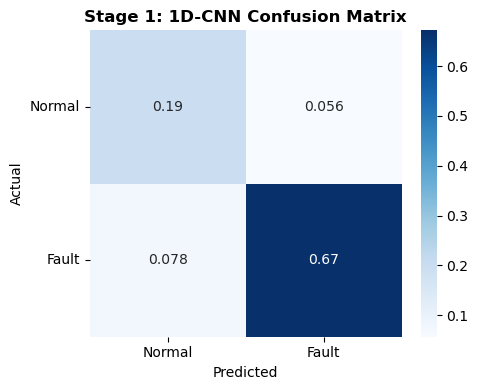

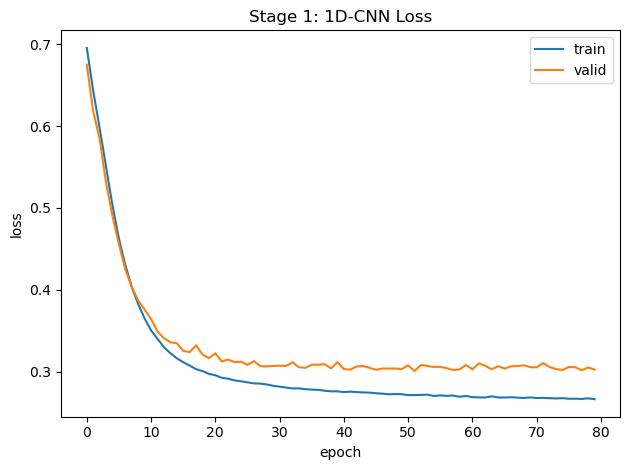

In [11]:
# ──────────────────────────────────────────────────────────────
# 8.  [STAGE 1] 평가 + Confusion Matrix + Loss 그래프
# ──────────────────────────────────────────────────────────────
model_1d = torch.load(SAVE_PATH + 'model_1d_binary.pt', weights_only=False)
model_1d.eval()

# 테스트 정확도
total = 0; correct = 0
y_pred_all = []; y_true_all = []
start_time = time.time()
with torch.no_grad():
    for x_t, y_t in test_loader1:
        out = model_1d(x_t)
        _, pred = torch.max(out, 1)
        total   += y_t.size(0)
        correct += (pred == y_t).sum().item()
        y_pred_all.extend(pred.numpy()); y_true_all.extend(y_t.numpy())
end_time = time.time()
print(f'[Stage 1] 1D-CNN Test Accuracy : {correct/total:.4f}')
print(f'[Stage 1] 1D-CNN Inference Time: {end_time - start_time:.4f} sec')
print(classification_report(y_true_all, y_pred_all, target_names=['Normal','Fault']))

# Confusion Matrix
plt.figure(figsize=(5,4))
cm1 = confusion_matrix(y_true_all, y_pred_all)
df_cm1 = pd.DataFrame(cm1/len(y_true_all), index=['Normal','Fault'], columns=['Normal','Fault'])
sns.heatmap(df_cm1, annot=True, cmap=plt.cm.Blues)
plt.title('Stage 1: 1D-CNN Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.yticks(rotation=0)
plt.tight_layout(); plt.savefig(SAVE_PATH + 'cm_stage1.png'); plt.show(); plt.close()

# Loss 그래프
plt.figure()
plt.plot(loss1_tr, label='train'); plt.plot(loss1_va, label='valid')
plt.title('Stage 1: 1D-CNN Loss'); plt.xlabel('epoch'); plt.ylabel('loss')
plt.legend(); plt.tight_layout()
plt.savefig(SAVE_PATH + 'loss_stage1.png'); plt.show(); plt.close()

In [12]:
# ──────────────────────────────────────────────────────────────
# 9.  [STAGE 1 → STAGE 2 연결]
#     1D-CNN이 Fault로 판별한 데이터만 추출 → .npz 저장
#     (Type1/Type2/Type3 전체 데이터에서 1D-CNN 추론 수행)
# ──────────────────────────────────────────────────────────────
model_1d = torch.load(SAVE_PATH + 'model_1d_binary.pt', weights_only=False)
model_1d.eval()

# Type1/2/3 원시 데이터 결합 (레이블 0=Type1, 1=Type2, 2=Type3)
fault_all  = np.concatenate([type1, type2, type3], axis=0)
fault_type = np.concatenate([np.zeros(len(type1)), np.ones(len(type2)), np.full(len(type3), 2)]).astype(np.int64)

x_fault_all = torch.from_numpy(fault_all).float()

# 1D-CNN 추론: Fault(=1)로 판별된 인덱스 추출
print('1D-CNN 추론 중...')
start_time = time.time()
with torch.no_grad():
    out_all     = model_1d(x_fault_all)
    pred_binary = torch.max(out_all, 1)[1].numpy()   # 0=Normal, 1=Fault
end_time = time.time()

fault_mask    = (pred_binary == 1)                   # Fault로 판별된 마스크
X_detected    = fault_all[fault_mask]                # Fault 판별 포인트
y_detected    = fault_type[fault_mask]               # 실제 유형 레이블 (Stage 2 정답)

print(f'[Stage 1 추론] 전체: {len(fault_all)} | Fault 탐지: {fault_mask.sum()} ({fault_mask.mean()*100:.1f}%)')
print(f'  추론 시간: {end_time - start_time:.4f} sec')
print(f'  Type1_탐지: {(y_detected==0).sum()} | Type2_탐지: {(y_detected==1).sum()} | Type3_탐지: {(y_detected==2).sum()}')

# .npz 저장
np.savez(SAVE_PATH + 'fault_detected.npz', X=X_detected, y=y_detected)
print(f'  저장 완료: {SAVE_PATH}fault_detected.npz')

1D-CNN 추론 중...
[Stage 1 추론] 전체: 300000 | Fault 탐지: 268821 (89.6%)
  추론 시간: 3.7848 sec
  Type1_탐지: 96312 | Type2_탐지: 74993 | Type3_탐지: 97516
  저장 완료: C:/Users/SPAC6/Desktop/python data/형민/save/Hybrid/fault_detected.npz


In [13]:
# ──────────────────────────────────────────────────────────────
# 10. [STAGE 2] fault_detected.npz 로드 → 슬라이딩 윈도우 → STFT
#     파라미터는 KAMP_STFT_2DCNN.ipynb와 동일
# ──────────────────────────────────────────────────────────────
data_loaded = np.load(SAVE_PATH + 'fault_detected.npz')
X_fault = data_loaded['X'].astype(np.float32)   # (N_fault, 4)
y_fault = data_loaded['y']                       # (N_fault,) 0=Type1/1=Type2/2=Type3
print(f'로드 완료: X_fault {X_fault.shape}, y_fault {y_fault.shape}')

# 슬라이딩 윈도우 파라미터
WINDOW_SIZE = 256
STRIDE      = 32
N_FFT       = 64
HOP_LENGTH  = 16

def make_windows_with_label(data, labels, window_size=WINDOW_SIZE, stride=STRIDE):
    """
    data   : (N, 4)
    labels : (N,)  — 포인트 단위 레이블
    Returns: windows (M, 4, W), win_labels (M,)  — 윈도우 레이블 = 최빈값
    """
    windows = []; win_labels = []
    for start in range(0, data.shape[0] - window_size + 1, stride):
        w = data[start:start+window_size].T       # (4, W)
        windows.append(w)
        lbl_seg = labels[start:start+window_size]
        win_labels.append(np.bincount(lbl_seg).argmax())
    return np.array(windows, dtype=np.float32), np.array(win_labels, dtype=np.int64)

windows, win_labels = make_windows_with_label(X_fault, y_fault)
print(f'슬라이딩 윈도우: {windows.shape}  레이블: {win_labels.shape}')
print(f'  Type1: {(win_labels==0).sum()} | Type2: {(win_labels==1).sum()} | Type3: {(win_labels==2).sum()}')

로드 완료: X_fault (268821, 4), y_fault (268821,)
슬라이딩 윈도우: (8393, 4, 256)  레이블: (8393,)
  Type1: 3006 | Type2: 2344 | Type3: 3043


In [14]:
# STFT 변환 (torch.stft, KAMP_STFT_2DCNN.ipynb 동일 방식)
def windows_to_stft(wins, n_fft=N_FFT, hop=HOP_LENGTH):
    """
    wins : (N, 4, W)
    Returns : (N, 4, freq_bins, time_frames) log-spectrogram
    """
    N, C, W = wins.shape
    freq_bins   = n_fft // 2 + 1
    time_frames = (W - n_fft) // hop + 1
    t = torch.from_numpy(wins.reshape(N * C, W))
    win_fn = torch.hann_window(n_fft)
    S = torch.stft(t, n_fft=n_fft, hop_length=hop, win_length=n_fft,
                   window=win_fn, center=False, return_complex=True)
    S_log = torch.log1p(S.abs())
    return S_log.reshape(N, C, freq_bins, time_frames).numpy()

print('STFT 변환 중...', end=' ')
start_time = time.time()
specs = windows_to_stft(windows)
end_time = time.time()
FREQ_BINS   = specs.shape[2]
TIME_FRAMES = specs.shape[3]
print(f'완료 ({end_time-start_time:.2f}초)')
print(f'스펙트로그램 형태: {specs.shape}  (N, 4채널, {FREQ_BINS} freq, {TIME_FRAMES} time)')

STFT 변환 중... 완료 (0.08초)
스펙트로그램 형태: (8393, 4, 33, 13)  (N, 4채널, 33 freq, 13 time)


C:\Users\SPAC6\AppData\Local\Temp\ipykernel_27632\2059793462.py:10: UserWarning: Glyph 51656 (\N{HANGUL SYLLABLE JIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(SAVE_PATH + 'stft_samples.png'); plt.show(); plt.close()
C:\Users\SPAC6\AppData\Local\Temp\ipykernel_27632\2059793462.py:10: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(SAVE_PATH + 'stft_samples.png'); plt.show(); plt.close()
C:\Users\SPAC6\AppData\Local\Temp\ipykernel_27632\2059793462.py:10: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(SAVE_PATH + 'stft_samples.png'); plt.show(); plt.close()
C:\Users\SPAC6\AppData\Local\Temp\ipykernel_27632\2059793462.py:10: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(SAVE_PATH + 'stft_samples.png'); plt.show(); plt.close()
C:\Users\SPAC6\AppDat

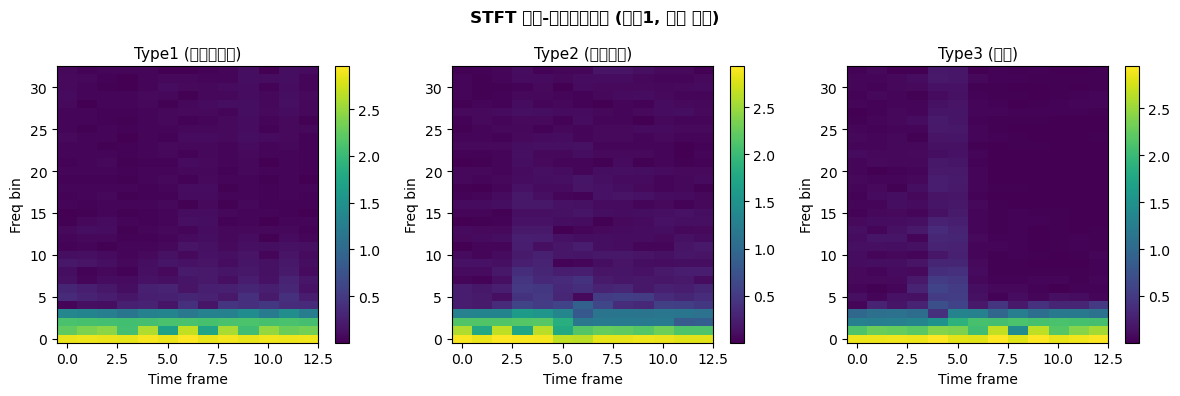

In [15]:
# 스펙트로그램 시각화 (유형별 대표 샘플)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
class_names = ['Type1 (질량불균형)', 'Type2 (지지불량)', 'Type3 (복합)']
for ax, cls, name in zip(axes, [0,1,2], class_names):
    idx = np.where(win_labels == cls)[0][0]
    im = ax.imshow(specs[idx, 0], aspect='auto', origin='lower', cmap='viridis')
    ax.set_title(name, fontsize=11); ax.set_xlabel('Time frame'); ax.set_ylabel('Freq bin')
    plt.colorbar(im, ax=ax)
plt.suptitle('STFT 로그-스펙트로그램 (센서1, 대표 샘플)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.savefig(SAVE_PATH + 'stft_samples.png'); plt.show(); plt.close()

In [16]:
# ──────────────────────────────────────────────────────────────
# 11. [STAGE 2] 2D-CNN 데이터셋 구성 (60/20/20 분할)
# ──────────────────────────────────────────────────────────────
n_total = len(specs)
t1s, t2s = int(n_total*0.6), int(n_total*0.8)

# 셔플
idx = np.random.permutation(n_total)
specs_shuf  = specs[idx]
labels_shuf = win_labels[idx]

train2 = specs_shuf[:t1s];  train_label2 = labels_shuf[:t1s]
valid2 = specs_shuf[t1s:t2s]; valid_label2 = labels_shuf[t1s:t2s]
test2  = specs_shuf[t2s:];  test_label2  = labels_shuf[t2s:]

x_train2 = torch.from_numpy(train2).float();   y_train2 = torch.from_numpy(train_label2).long()
x_valid2 = torch.from_numpy(valid2).float();   y_valid2 = torch.from_numpy(valid_label2).long()
x_test2  = torch.from_numpy(test2).float();    y_test2  = torch.from_numpy(test_label2).long()

BATCH_SIZE = 128
train_loader2 = DataLoader(TensorDataset(x_train2, y_train2), batch_size=BATCH_SIZE, shuffle=True)
valid_loader2 = DataLoader(TensorDataset(x_valid2, y_valid2), batch_size=len(x_valid2), shuffle=False)
test_loader2  = DataLoader(TensorDataset(x_test2,  y_test2),  batch_size=len(x_test2),  shuffle=False)

print(f'[Stage 2] Train: {len(train2)} | Valid: {len(valid2)} | Test: {len(test2)}')


[Stage 2] Train: 5035 | Valid: 1679 | Test: 1679


In [17]:
# ──────────────────────────────────────────────────────────────
# 12. [STAGE 2] 2D-CNN 모델 정의 (KAMP_STFT_CNN2D 동일 구조, 출력=3)
# ──────────────────────────────────────────────────────────────
class KAMP_STFT_CNN2D_Fault(nn.Module):
    """Stage 2: Type1(0)/Type2(1)/Type3(2) 3클래스 분류"""
    def __init__(self):
        super(KAMP_STFT_CNN2D_Fault, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(4, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), nn.Dropout(p=0.2))
        self.conv2 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), nn.Dropout(p=0.2))
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 3, kernel_size=3, stride=1, padding=1),   # 출력채널=3
            nn.BatchNorm2d(3), nn.ReLU(),
            nn.MaxPool2d(kernel_size=1, stride=1))
        self.final_pool = nn.AdaptiveAvgPool2d(1)
        self.linear = nn.Linear(3, 3)

    def forward(self, x):
        x = self.conv1(x); x = self.conv2(x); x = self.conv3(x)
        x = self.final_pool(x)
        return self.linear(x.view(x.size(0), -1))

model_2d = KAMP_STFT_CNN2D_Fault()
print(model_2d)
dummy = torch.randn(1, 4, FREQ_BINS, TIME_FRAMES)
print('\n입력 형태:', dummy.shape, '→ 출력 형태:', model_2d(dummy).shape)

KAMP_STFT_CNN2D_Fault(
  (conv1): Sequential(
    (0): Conv2d(4, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.2, inplace=False)
  )
  (conv2): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.2, inplace=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=1, stride=1, padding=0, dilation=1, ceil_mode=False)
  )
  (final_pool): AdaptiveAvgPo

In [18]:
# ──────────────────────────────────────────────────────────────
# 13. [STAGE 2] 2D-CNN 학습 + 계산 시간 측정
# ──────────────────────────────────────────────────────────────
def train_model_2d(model, criterion, optimizer, num_epochs, train_loader, valid_loader, PATH, fname):
    loss_values = []; loss_values_v = []
    check = 0; accuracy_past = 0.0

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss = 0.0; batch_number = 0
        for x_batch, y_batch in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(x_batch), y_batch)
            loss.backward(); optimizer.step()
            running_loss += loss.item(); batch_number += 1
        loss_values.append(running_loss / batch_number)

        model.eval(); accuracy = 0.0; total = 0.0
        with torch.no_grad():
            for x_v, y_v in valid_loader:
                v_hat = model(x_v); v_loss = criterion(v_hat, y_v)
                _, pred = torch.max(v_hat, 1)
                total    += y_v.size(0)
                accuracy += (pred == y_v).sum().item()
        loss_values_v.append(v_loss.item())
        accuracy /= total

        if epoch % 1 == 0:
            print(f'[Epoch {epoch}/{num_epochs}] Train_Loss: {loss.item():.6f} | Valid_Loss: {v_loss.item():.6f} | Acc: {accuracy:.4f}')

        if accuracy_past > accuracy:
            check += 1
        else:
            check = 0; accuracy_past = accuracy
        if check > 50:
            print('조기 종료 발동!')
            torch.save(model, PATH + fname)
            return loss_values, loss_values_v

    torch.save(model, PATH + fname)
    return loss_values, loss_values_v

model_2d   = KAMP_STFT_CNN2D_Fault()
criterion  = nn.CrossEntropyLoss()
optimizer2 = torch.optim.Adam(model_2d.parameters())
NUM_EPOCHS_2D = 100

start_time = time.time()
loss2_tr, loss2_va = train_model_2d(
    model_2d, criterion, optimizer2, NUM_EPOCHS_2D,
    train_loader2, valid_loader2, SAVE_PATH, 'model_2d_fault.pt')
end_time = time.time()
print(f'\n[Stage 2] 2D-CNN Training Time: {end_time - start_time:.2f} sec')

[Epoch 10/100] Train_Loss: 0.555443 | Valid_Loss: 0.454259 | Acc: 0.9869
[Epoch 20/100] Train_Loss: 0.201612 | Valid_Loss: 0.250347 | Acc: 0.9994
[Epoch 30/100] Train_Loss: 0.138398 | Valid_Loss: 0.144663 | Acc: 0.9994
[Epoch 40/100] Train_Loss: 0.088950 | Valid_Loss: 0.095255 | Acc: 1.0000
[Epoch 50/100] Train_Loss: 0.079918 | Valid_Loss: 0.062414 | Acc: 0.9994
[Epoch 60/100] Train_Loss: 0.047941 | Valid_Loss: 0.045791 | Acc: 1.0000
[Epoch 70/100] Train_Loss: 0.061017 | Valid_Loss: 0.033871 | Acc: 0.9994
[Epoch 80/100] Train_Loss: 0.021968 | Valid_Loss: 0.026323 | Acc: 1.0000
[Epoch 90/100] Train_Loss: 0.017487 | Valid_Loss: 0.019734 | Acc: 1.0000
[Epoch 100/100] Train_Loss: 0.015539 | Valid_Loss: 0.016407 | Acc: 1.0000

[Stage 2] 2D-CNN Training Time: 285.57 sec


[Stage 2] 2D-CNN Test Accuracy : 1.0000
[Stage 2] 2D-CNN Inference Time: 0.2543 sec
              precision    recall  f1-score   support

       Type1       1.00      1.00      1.00       608
       Type2       1.00      1.00      1.00       460
       Type3       1.00      1.00      1.00       611

    accuracy                           1.00      1679
   macro avg       1.00      1.00      1.00      1679
weighted avg       1.00      1.00      1.00      1679



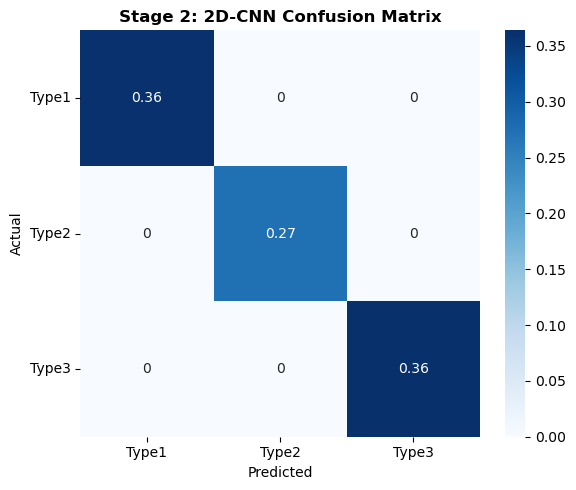

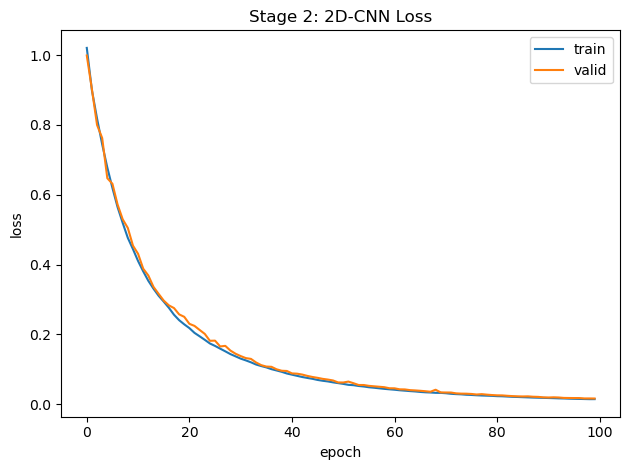

In [19]:
# ──────────────────────────────────────────────────────────────
# 14. [STAGE 2] 평가 + Confusion Matrix + Loss 그래프
# ──────────────────────────────────────────────────────────────
model_2d = torch.load(SAVE_PATH + 'model_2d_fault.pt', weights_only=False)
model_2d.eval()

y_pred2 = []; y_true2 = []; total2 = 0; correct2 = 0
start_time = time.time()
with torch.no_grad():
    for x_t, y_t in test_loader2:
        out = model_2d(x_t)
        _, pred = torch.max(out, 1)
        total2   += y_t.size(0)
        correct2 += (pred == y_t).sum().item()
        y_pred2.extend(pred.numpy()); y_true2.extend(y_t.numpy())
end_time = time.time()

print(f'[Stage 2] 2D-CNN Test Accuracy : {correct2/total2:.4f}')
print(f'[Stage 2] 2D-CNN Inference Time: {end_time - start_time:.4f} sec')
print(classification_report(y_true2, y_pred2, target_names=['Type1','Type2','Type3']))

# Confusion Matrix
plt.figure(figsize=(6,5))
cm2 = confusion_matrix(y_true2, y_pred2)
df_cm2 = pd.DataFrame(cm2/len(y_true2), index=['Type1','Type2','Type3'], columns=['Type1','Type2','Type3'])
sns.heatmap(df_cm2, annot=True, cmap=plt.cm.Blues)
plt.title('Stage 2: 2D-CNN Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.yticks(rotation=0)
plt.tight_layout(); plt.savefig(SAVE_PATH + 'cm_stage2.png'); plt.show(); plt.close()

# Loss 그래프
plt.figure()
plt.plot(loss2_tr, label='train'); plt.plot(loss2_va, label='valid')
plt.title('Stage 2: 2D-CNN Loss'); plt.xlabel('epoch'); plt.ylabel('loss')
plt.legend(); plt.tight_layout()
plt.savefig(SAVE_PATH + 'loss_stage2.png'); plt.show(); plt.close()

In [20]:
# ──────────────────────────────────────────────────────────────
# 15. [최종] 하이브리드 단일 추론 함수
#     입력: 센서 포인트 1개 (shape: (4,))
#     출력: 'Normal' | 'Fault - Type1' | 'Fault - Type2' | 'Fault - Type3'
# ──────────────────────────────────────────────────────────────
model_1d = torch.load(SAVE_PATH + 'model_1d_binary.pt', weights_only=False); model_1d.eval()
model_2d = torch.load(SAVE_PATH + 'model_2d_fault.pt',  weights_only=False); model_2d.eval()

def hybrid_predict(sensor_window_256pts):
    """
    sensor_window_256pts : ndarray (256, 4) — 직전 256 포인트의 4센서 값
    Returns  : (result_str, p_fault)
    """
    # Stage 1: 1D-CNN — 임의로 중간 포인트 1개를 대표값으로 사용
    repr_point = torch.from_numpy(sensor_window_256pts[128].astype(np.float32)).unsqueeze(0)  # (1,4)
    with torch.no_grad():
        out1 = model_1d(repr_point)
        probs1 = torch.softmax(out1, dim=1)
        p_fault = probs1[0, 1].item()
        pred1   = torch.max(out1, 1)[1].item()

    if pred1 == 0:
        return 'Normal', p_fault

    # Stage 2: 2D-CNN — 윈도우 전체를 STFT 변환 후 입력
    win_t  = torch.from_numpy(sensor_window_256pts.T).float().unsqueeze(0)  # (1, 4, 256)
    win_fn = torch.hann_window(N_FFT)
    S      = torch.stft(win_t.reshape(4, WINDOW_SIZE), n_fft=N_FFT, hop_length=HOP_LENGTH,
                        win_length=N_FFT, window=win_fn, center=False, return_complex=True)
    S_log  = torch.log1p(S.abs()).unsqueeze(0)   # (1, 4, FREQ, TIME)

    with torch.no_grad():
        out2   = model_2d(S_log)
        type_i = torch.max(out2, 1)[1].item()

    return f'Fault - {["Type1","Type2","Type3"][type_i]}', p_fault

print('hybrid_predict 함수 준비 완료')

hybrid_predict 함수 준비 완료


In [21]:
# ──────────────────────────────────────────────────────────────
# 16. 샘플 추론 테스트
# ──────────────────────────────────────────────────────────────
test_cases = [
    ('Normal', normal),
    ('Type1',  type1),
    ('Type2',  type2),
    ('Type3',  type3),
]
print('='*55)
print(f'{"실제 상태":10s}  {"예측 결과":25s}  {"P(Fault)":>8s}  {"시간":>8s}')
print('='*55)
for state, arr in test_cases:
    sample = arr[:WINDOW_SIZE]           # 첫 256 포인트
    t_s = time.time()
    result, score = hybrid_predict(sample)
    t_e = time.time()
    print(f'{state:10s}  {result:25s}  {score:.4f}    {(t_e-t_s)*1000:.1f}ms')
print('='*55)
print(f'\n저장 위치: {SAVE_PATH}')

실제 상태       예측 결과                      P(Fault)        시간
Normal      Normal                     0.4751    1.5ms
Type1       Fault - Type1              0.7099    2.3ms
Type2       Fault - Type2              0.8249    1.9ms
Type3       Fault - Type3              0.9988    1.3ms

저장 위치: C:/Users/SPAC6/Desktop/python data/형민/save/Hybrid/
